# Apuntes Extensos: Vision Transformers (ViT) — Replicación del Paper

**Paper original:** *"An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"* (Dosovitskiy et al., 2020)

---

Este notebook constituye una guía completa y autocontenida sobre la arquitectura **Vision Transformer (ViT)**, cubriendo desde la teoría matemática del paper original hasta la implementación práctica en PyTorch, incluyendo entrenamiento desde cero, Transfer Learning e inferencia.

**Objetivos de este documento:**
1. Comprender qué es un paper de Machine Learning y por qué replicarlos.
2. Entender la intuición y la teoría detrás de ViT mediante analogías y rigor matemático.
3. Analizar la trazabilidad dimensional de tensores a través de las 4 ecuaciones del paper.
4. Evaluar la complejidad computacional y sus implicaciones prácticas.
5. Implementar la arquitectura completa en PyTorch.
6. Entrenar el modelo desde cero y analizar los resultados.
7. Aplicar Transfer Learning con un ViT preentrenado.
8. Realizar inferencia sobre imágenes nuevas.

## 0. Introducción: Papers de Machine Learning y Terminología

### 0.1 ¿Qué es un paper de Machine Learning?

Un paper de investigación en ML es un documento científico que condensa meses (o años) de trabajo de un equipo investigador. Su estructura típica es:

| **Sección** | **Contenido** |
| --- | --- |
| **Abstract** | Resumen de los hallazgos principales. |
| **Introduction** | Problema abordado y métodos previos. |
| **Method** | Descripción del modelo, datos y configuración experimental. |
| **Results** | Resultados y comparación con el estado del arte. |
| **Conclusion** | Limitaciones y trabajo futuro. |
| **References** | Fuentes bibliográficas consultadas. |

### 0.2 ¿Por qué replicar papers?

Replicar papers es una de las formas más efectivas de mejorar como ingeniero/científico de ML. Como dijo George Hotz (fundador de comma.ai):

> *"Descarga un paper, impleméntalo y sigue haciéndolo hasta que tengas habilidades."*

### 0.3 Terminología clave

* **ViT** — Vision Transformer. La arquitectura que estamos replicando.
* **MSA** — Multi-Head Self-Attention. El mecanismo que permite a cada parche "mirar" a todos los demás.
* **MLP** — Multilayer Perceptron. Red feed-forward de dos capas con activación GELU.
* **LN** — Layer Normalization. Normalización aplicada *antes* de cada sub-capa.
* **Patch Embedding** — Proyección lineal que convierte parches de imagen en vectores de dimensión $D$.
* **Class Token** — Un token aprendible especial que acumula información global para la clasificación.
* **Position Embedding** — Vectores aprendibles que codifican la posición espacial de cada parche.
* **Transformer Encoder** — Bloque que combina MSA + MLP con conexiones residuales. Se apilan $L$ veces.
* **MLP Head** — Cabezal de clasificación final.

## 1. Preparación de Datos

En esta sección preparamos el dataset **FoodVision Mini** (pizza, steak, sushi) siguiendo las especificaciones del paper ViT:
- Resolución de entrenamiento: **224×224** (Tabla 3 del paper).
- Batch size: **32** (el paper usa 4096, pero necesitamos hardware de Google para eso).

In [1]:
# --- Imports y configuración base ---
import torch
import torchvision
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from torch import nn
from torchvision import transforms

# Device-agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Usando dispositivo: cuda
torch version: 2.12.0+cu126
torchvision version: 0.27.0+cu126


### 1.1 Descarga del dataset y creación de DataLoaders

Utilizamos el módulo `data_setup` de `going_modular` para crear los DataLoaders.
La resolución de entrenamiento del ViT paper (Tabla 3) es **224×224**.

In [2]:
from pathlib import Path

# Transforms manuales (sin normalización porque entrenaremos desde cero primero)
IMG_SIZE = 224

manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Transforms manuales: {manual_transforms}")

# Directorios de datos
train_dir = Path('../data/pizza_steak_sushi/train')
test_dir = Path('../data/pizza_steak_sushi/test')

# Crear DataLoaders
BATCH_SIZE = 32

from going_modular.going_modular import data_setup

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)

print(f"Clases: {class_names}")
print(f"Batches de entrenamiento: {len(train_dataloader)}")
print(f"Batches de test: {len(test_dataloader)}")

Transforms manuales: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
Clases: ['pizza', 'steak', 'sushi']
Batches de entrenamiento: 8
Batches de test: 3


### 1.2 Visualización de una imagen

Antes de crear parches, visualicemos una imagen del dataset para entender qué estamos procesando.

Shape de la imagen: torch.Size([3, 224, 224])
Clase: sushi


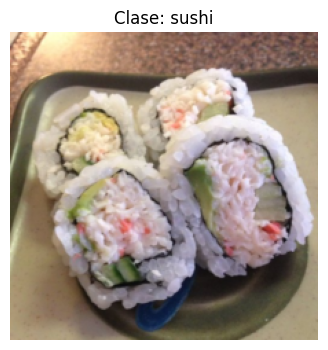

In [3]:
# Obtener un batch de imágenes
image_batch, label_batch = next(iter(train_dataloader))
image, label = image_batch[0], label_batch[0]

print(f"Shape de la imagen: {image.shape}")  # [C, H, W] = [3, 224, 224]
print(f"Clase: {class_names[label]}")

# Visualizar
plt.figure(figsize=(4, 4))
plt.imshow(image.permute(1, 2, 0))  # [C,H,W] -> [H,W,C] para matplotlib
plt.title(f"Clase: {class_names[label]}")
plt.axis('off')
plt.show()

## 2. Teoría, Ecuaciones, Trazabilidad y Analogías

La arquitectura ViT se define formalmente mediante **4 ecuaciones matemáticas** (sección 3.1 del paper). A continuación las desglosamos con rigor matemático — rastreando la evolución exacta de las dimensiones de los tensores — y con analogías intuitivas.

### 2.1 Tabla 1 del paper: Variantes de ViT

Antes de entrar en las ecuaciones, es fundamental conocer los hiperparámetros de cada variante:

| Modelo | Capas ($L$) | Hidden size ($D$) | MLP size | Cabezales | Parámetros |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **ViT-Base** | 12 | 768 | 3072 | 12 | ~86M |
| **ViT-Large** | 24 | 1024 | 4096 | 16 | ~307M |
| **ViT-Huge** | 32 | 1280 | 5120 | 16 | ~632M |

Nosotros replicaremos **ViT-Base** (empezar pequeño, escalar después).

**Desglose de hiperparámetros:**
- **Layers ($L$):** Cuántos bloques Transformer Encoder se apilan.
- **Hidden size ($D$):** Dimensión del embedding a lo largo de toda la arquitectura. Mayor $D$ = más capacidad = más cómputo.
- **MLP size:** Unidades ocultas en el bloque MLP (típicamente $4 \times D$).
- **Heads:** Número de cabezales de atención en MSA (cada uno opera sobre $D/\text{heads}$ dimensiones).
- **Params:** Total de parámetros entrenables del modelo.

### 2.2 Ecuación 1: Patch Embedding — La Proyección Lineal de Parches

$$\mathbf{z}_0 = [\mathbf{x}_{\text{class}}; \, \mathbf{x}^1_p \mathbf{E}; \, \mathbf{x}^2_p \mathbf{E}; \, \cdots; \, \mathbf{x}^N_p \mathbf{E}] + \mathbf{E}_{\text{pos}}, \qquad \mathbf{E} \in \mathbb{R}^{(P^2 \cdot C) \times D}, \; \mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$$

Esta ecuación transforma una imagen 2D en una secuencia 1D que el Transformer pueda procesar.

#### Trazabilidad Dimensional (paso a paso)

Dada una imagen de entrada $\mathbf{x} \in \mathbb{R}^{H \times W \times C}$:

| Paso | Operación | Dimensión resultante | Ejemplo (ViT-Base) |
|------|-----------|---------------------|---------------------|
| 0 | Imagen de entrada | $H \times W \times C$ | $224 \times 224 \times 3$ |
| 1 | **Patching:** Extraer $N$ parches de $(P \times P)$ | $N$ parches de tamaño $P \times P \times C$ | $N = \frac{224^2}{16^2} = 196$ parches de $16 \times 16 \times 3$ |
| 2 | **Flattening:** Aplanar cada parche | $N \times (P^2 \cdot C)$ | $196 \times 768$ |
| 3 | **Proyección ($\mathbf{E}$):** Multiplicar por matriz aprendible | $N \times D$ | $196 \times 768$ |
| 4 | **Prepend class token:** Concatenar $\mathbf{x}_{\text{class}} \in \mathbb{R}^{1 \times D}$ | $(N+1) \times D$ | $197 \times 768$ |
| 5 | **Sumar posición:** $+ \mathbf{E}_{\text{pos}} \in \mathbb{R}^{(N+1) \times D}$ | $(N+1) \times D$ | $197 \times 768$ |

**Salida final:** $\mathbf{z}_0 \in \mathbb{R}^{(N+1) \times D}$. Con batch: `[Batch, 197, 768]`.

> **Nota:** En la implementación usamos `nn.Conv2d` con `kernel_size=P` y `stride=P`. Esto realiza simultáneamente el patching, flattening y proyección en una sola operación eficiente.

#### La Intuición

Imagina que tienes una foto gigante. Un Transformer no puede mirarla toda de golpe:
1. **Cortar (Patching):** Recortamos la imagen en cuadraditos de $16 \times 16$.
2. **Aplanar y Comprimir (Matriz $\mathbf{E}$):** Cada cuadradito se aplasta en una tira larga de píxeles y se multiplica por una matriz de pesos aprendible, generando un "resumen numérico" de longitud fija $D=768$.

**Componentes extra clave:**
- **El `class_token` ($\mathbf{x}_{\text{class}}$):** Al principio de la fila de parches, añadimos un parche "comodín" en blanco. Este viajará junto a todos los demás interactuando con ellos. Su misión: recolectar información global y, al final, ser el *único* que se usa para predecir la clase.
- **Embeddings de Posición ($\mathbf{E}_{\text{pos}}$):** Al cortar y poner en fila, perdemos el orden espacial. El embedding de posición soluciona esto sumando una "etiqueta GPS" aprendible a cada parche, permitiendo al Transformer saber dónde estaba cada uno originalmente.

### 2.3 Ecuaciones 2 y 3: El Bloque Transformer Encoder

El Transformer Encoder de ViT repite el siguiente bloque $L$ veces (12 para ViT-Base):

**Ecuación 2:** $$\mathbf{z}'_l = \text{MSA}(\text{LN}(\mathbf{z}_{l-1})) + \mathbf{z}_{l-1}, \qquad l = 1 \ldots L$$

**Ecuación 3:** $$\mathbf{z}_l = \text{MLP}(\text{LN}(\mathbf{z}'_l)) + \mathbf{z}'_l, \qquad l = 1 \ldots L$$

#### Trazabilidad Dimensional

Tanto la entrada $\mathbf{z}_{l-1}$ como la salida $\mathbf{z}_l$ mantienen **estrictamente** la misma dimensión: $\mathbb{R}^{(N+1) \times D}$ (ej. `[197, 768]`).

Ni LayerNorm, ni MSA, ni MLP alteran el número de parches ni su dimensión profunda, garantizando que todos los bloques sean apilables sin ajuste.

| Operación | Entrada | Salida | Notas |
|-----------|---------|--------|-------|
| LN (pre-MSA) | `[197, 768]` | `[197, 768]` | Normaliza por token |
| MSA | `[197, 768]` | `[197, 768]` | $Q, K, V$ se proyectan a $D$, se dividen en $h$ cabezales |
| Residual (+) | — | `[197, 768]` | Suma la entrada original |
| LN (pre-MLP) | `[197, 768]` | `[197, 768]` | Normaliza por token |
| MLP | `[197, 768]` | `[197, 768]` | Expande a $4D=3072$, luego reduce a $D=768$ |
| Residual (+) | — | `[197, 768]` | Suma la entrada del sub-bloque |

#### La Analogía de la Fábrica

Imagina el modelo ViT como una **fábrica con una línea de montaje**. Los datos (la secuencia de parches + class token) son una **bandeja con múltiples compartimentos** que avanza por la cinta transportadora. Cada "Bloque Transformer" es una **estación de trabajo** con dos procesos:

#### 2.3.1 Comunicación Global: Multi-Head Self-Attention (MSA)

**¿Qué pasa?** Los parches "hablan" entre sí. La red evalúa qué partes de la imagen son relevantes para otras partes.

**La Analogía del Excursionista:** Imagina a varios excursionistas (los parches) observando un paisaje. El parche de la "oreja de un perro" mira a los demás preguntando: *"¿Alguno ve una nariz, ojos o pelo para confirmar que juntos formamos un perro?"*. Todos intercambian información para ganar **contexto global** sobre qué están formando.

**Mecánica interna:**
- El MSA genera tres matrices: **Query** ($Q$), **Key** ($K$) y **Value** ($V$), mediante tres proyecciones lineales.
- Se calcula una **matriz de atención** $\text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$, donde cada celda indica "cuánto le importa el parche $i$ al parche $j$".
- **Multi-Head** significa que este proceso se repite $h$ veces (12 en ViT-Base) en sub-espacios independientes. Cada "cabezal" se fija en aspectos diferentes de las relaciones entre parches.

#### 2.3.2 Procesamiento Individual: Multilayer Perceptron (MLP)

**¿Qué pasa?** Después de hablar con los demás, cada parche procesa **individualmente** la nueva información recibida.

**En la Fábrica:** Es como si hubiera un operario dedicado exclusivamente a cada compartimento de la bandeja. Operan sobre cada parche por separado sin mezclarlos.

**Estructura del MLP:**
```
Linear(D → 4D) → GELU → Dropout → Linear(4D → D) → Dropout
```
Para ViT-Base: `Linear(768 → 3072) → GELU → Dropout → Linear(3072 → 768) → Dropout`

> **¿Por qué GELU y no ReLU?** GELU (*Gaussian Error Linear Unit*) es una activación más suave que ReLU. Mientras ReLU corta abruptamente en cero, GELU pondera la entrada por su probabilidad bajo una distribución gaussiana, lo que resulta en gradientes más estables durante el entrenamiento de modelos grandes.

#### 2.3.3 Los Guardianes: Layer Normalization y Conexiones Residuales

- **Layer Normalization (LN):** Antes de que un parche entre a MSA o MLP, sus valores se normalizan (se centran y escalan). Esto previene que los valores numéricos "estallen" o "se desvanezcan" a medida que la señal atraviesa las $L$ capas del modelo. En ViT se aplica la normalización **pre-norm** (antes de la sub-capa), a diferencia del Transformer original que usaba **post-norm**.

- **Conexiones Residuales (`+ z`):** El símbolo `+` en las ecuaciones es crítico. Significa que la salida de MSA/MLP se **suma** a la entrada original del sub-bloque. En la fábrica, la bandeja avanza por la cinta principal inalterada, mientras que los procesos (MSA/MLP) actúan como ramas laterales que leen, operan y *suman* nueva información. Esto combate el **desvanecimiento de gradientes** en redes profundas y permite entrenar modelos con docenas de capas.

### 2.4 Ecuación 4: La Decisión Final (El Inspector)

$$\mathbf{y} = \text{LN}(\mathbf{z}_{L}^{0})$$

Una vez que el tensor sale de la última capa $L$: $\mathbf{z}_L \in \mathbb{R}^{(N+1) \times D}$.

El superíndice $0$ indica que extraemos **únicamente la primera fila** del tensor: el **class token** final. El vector resultante $\mathbf{z}_{L}^{0} \in \mathbb{R}^{D}$ (768 dimensiones) representa un resumen comprimido de toda la imagen, modelado globalmente.

Se normaliza con una última capa LayerNorm y se pasa por un cabezal lineal (`nn.Linear(D, num_classes)`) para producir los logits de clasificación.

#### La Analogía del Inspector

La bandeja ha pasado por las $L$ estaciones de la fábrica y llega al final de la línea. El inspector:
1. **Descarta** todos los compartimentos con información de los parches de la imagen.
2. **Extrae** únicamente la ficha del compartimento 0 (el `class_token`).
3. **Limpia** los datos con una última normalización (LN).
4. **Etiqueta** el producto pasando el vector por una capa lineal que produce la predicción final.

```python
# En pseudocódigo:
y = Linear(LN(z_L[:, 0]))  # [:, 0] selecciona el class token de cada muestra del batch
```

## 3. Complejidad Computacional e Interpretabilidad

### 3.1 El Cuello de Botella de ViT: Complejidad $O(N^2)$

Una de las mayores barreras académicas y prácticas del Vision Transformer frente a las CNN es su complejidad computacional.

Mientras que una convolución estándar calcula dependencias **puramente locales** con un coste que crece linealmente con la cantidad de píxeles, el **mecanismo de Self-Attention** compara *cada parche con todos los demás simultáneamente*.

**Matemáticamente:** Para construir la matriz de atención se realiza el producto $\mathbf{Q} \times \mathbf{K}^T$. Si la secuencia tiene $N$ elementos de dimensión $D$:

$$\text{Complejidad temporal y espacial de Self-Attention} = \mathcal{O}(N^2 \cdot D)$$

**Implicación práctica:** Si no usáramos parches y aplicáramos ViT píxel a píxel en una imagen $224 \times 224$, tendríamos $N = 50{,}176$ tokens. La matriz de atención sería de $50{,}176 \times 50{,}176$ — requiriendo cálculos y memoria masivos, haciendo el modelo inviable.

Por eso ViT usa **parches** de $16 \times 16$, reduciendo $N$ a tan solo $196$. Aún así, escalar ViT a imágenes de $1024 \times 1024$ (donde $N = 4{,}096$) sigue siendo extremadamente costoso.

| Resolución | Patch size | $N$ (tokens) | Tamaño de la matriz de atención |
|---|---|---|---|
| $224 \times 224$ | $16$ | $196$ | $196 \times 196 = 38{,}416$ |
| $224 \times 224$ | $1$ (píxel) | $50{,}176$ | $50{,}176 \times 50{,}176 \approx 2.5 \times 10^9$ |
| $1024 \times 1024$ | $16$ | $4{,}096$ | $4{,}096 \times 4{,}096 \approx 1.7 \times 10^7$ |

### 3.2 Interpretabilidad Visual: Attention Maps

A cambio del coste computacional, ViT ofrece una ventaja significativa para la investigación y la **IA Explicable (XAI)**: los **mapas de atención**.

El cálculo de atención genera explícitamente probabilidades entre `0` y `1` que expresan "cuánto le importa el parche A al parche B". Estos pesos pueden extraerse y visualizarse sobre la imagen original, permitiendo saber literalmente qué partes de la imagen fueron determinantes para la clasificación del modelo.

Esto contrasta con las CNN, donde la interpretabilidad requiere técnicas indirectas como Grad-CAM o mapas de saliencia.

## 4. Arquitectura ViT en PyTorch

A continuación implementamos las piezas clave de la arquitectura, pieza por pieza.

> **Nota:** Las celdas de código de esta sección contienen las definiciones de los modelos. Son ilustrativas y formativas: muestran la lógica y las dimensiones en cada paso.

### 4.1 PatchEmbedding — Ecuación 1

Convierte una imagen 2D en una secuencia 1D de patch embeddings. Usamos `nn.Conv2d` con `kernel_size=patch_size` y `stride=patch_size` como truco computacional equivalente a cortar + aplanar + proyectar.

In [4]:
import torch
from torch import nn

class PatchEmbedding(nn.Module):
    """Convierte una imagen 2D en una secuencia de parches unidimensionales (Ecuación 1).
    
    Flujo dimensional:
        Entrada:  [Batch, 3, 224, 224]
        Conv2d:   [Batch, 768, 14, 14]    (kernel=16, stride=16 -> 224/16=14)
        Flatten:  [Batch, 768, 196]        (14*14 = 196 parches)
        Permute:  [Batch, 196, 768]        (secuencia de N parches de dimensión D)
    """
    def __init__(self, in_channels: int = 3, patch_size: int = 16, embedding_dim: int = 768):
        super().__init__()
        self.patch_size = patch_size
        
        # Conv2d con kernel y stride = patch_size realiza:
        # 1) Patching (ventana deslizante sin solapamiento)
        # 2) Flattening (la convolución ya produce un escalar por filtro y posición)
        # 3) Proyección lineal (los pesos del filtro son la matriz E)
        self.patcher = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embedding_dim,
            kernel_size=patch_size,
            stride=patch_size,
            padding=0
        )
        
        # Aplana las dimensiones espaciales (H', W') en una sola dimensión secuencial
        self.flatten = nn.Flatten(start_dim=2, end_dim=3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x.shape: [Batch, C, H, W] = [B, 3, 224, 224]
        x_patched = self.patcher(x)       # -> [B, 768, 14, 14]
        x_flattened = self.flatten(x_patched)  # -> [B, 768, 196]
        # Rearreglar a: [Batch, N_parches, D_embedding]
        return x_flattened.permute(0, 2, 1)    # -> [B, 196, 768]

### 4.2 MultiheadSelfAttentionBlock — Ecuación 2

Este bloque implementa la primera mitad de cada capa del Transformer: `MSA(LN(z)) + z`.

PyTorch proporciona `nn.MultiheadAttention`, que gestiona internamente las proyecciones Q, K, V y la división en múltiples cabezales.

In [5]:
class MultiheadSelfAttentionBlock(nn.Module):
    """Ecuación 2: MSA(LN(z)) + z
    
    Dimensiones invariantes: [Batch, N+1, D] -> [Batch, N+1, D]
    """
    def __init__(self, embedding_dim: int = 768, num_heads: int = 12, attn_dropout: float = 0):
        super().__init__()
        # Pre-norm: LayerNorm ANTES de la atención
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        
        # nn.MultiheadAttention gestiona Q, K, V internamente.
        # num_heads=12 divide D=768 en 12 cabezales de 64 dimensiones cada uno.
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True  # Esperamos [Batch, Seq, Dim]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(
            query=x, key=x, value=x,  # Self-attention: Q=K=V=x
            need_weights=False
        )
        return attn_output

### 4.3 MLPBlock — Ecuación 3

Este bloque implementa la segunda mitad de cada capa: `MLP(LN(z')) + z'`.

Estructura interna: `Linear(D → 4D) → GELU → Dropout → Linear(4D → D) → Dropout`

In [6]:
class MLPBlock(nn.Module):
    """Ecuación 3: MLP(LN(z')) + z'
    
    Dimensiones: [Batch, N+1, D] -> [Batch, N+1, D]
    Internamente expande a 4D y reduce de vuelta a D.
    """
    def __init__(self, embedding_dim: int = 768, mlp_size: int = 3072, dropout: float = 0.1):
        super().__init__()
        # Pre-norm
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim, out_features=mlp_size),   # 768 -> 3072
            nn.GELU(),           # Activación no lineal suave
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, out_features=embedding_dim),   # 3072 -> 768
            nn.Dropout(p=dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(self.layer_norm(x))

### 4.4 TransformerEncoderBlock — Ecuaciones 2 y 3 integradas

Combina MSA y MLP con sus respectivas conexiones residuales.

In [7]:
class TransformerEncoderBlock(nn.Module):
    """Bloque Transformer Encoder completo (Ecuaciones 2 y 3).
    
    Dimensiones invariantes: [Batch, N+1, D] -> [Batch, N+1, D]
    Se apilan L de estos bloques en secuencia.
    """
    def __init__(self, embedding_dim: int = 768, num_heads: int = 12,
                 mlp_size: int = 3072, mlp_dropout: float = 0.1, attn_dropout: float = 0):
        super().__init__()
        self.msa_block = MultiheadSelfAttentionBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )
        self.mlp_block = MLPBlock(
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            dropout=mlp_dropout
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Ecuación 2: z'_l = MSA(LN(z_{l-1})) + z_{l-1}
        x = self.msa_block(x) + x
        
        # Ecuación 3: z_l = MLP(LN(z'_l)) + z'_l
        x = self.mlp_block(x) + x
        return x

### 4.5 ViT Completo — Uniendo todas las piezas

La clase principal ensambla: Patch Embedding + Class Token + Position Embedding + Stack de Transformer Encoders + Clasificador.

In [8]:
class ViT(nn.Module):
    """Vision Transformer completo con hiperparámetros de ViT-Base por defecto.
    
    Flujo del forward:
        [B, 3, 224, 224]       -- PatchEmbedding -->    [B, 196, 768]
        [B, 196, 768]          -- Prepend class_token -> [B, 197, 768]
        [B, 197, 768]          -- + position_emb -->     [B, 197, 768]
        [B, 197, 768]          -- Dropout -->            [B, 197, 768]
        [B, 197, 768]          -- L x TransformerEnc --> [B, 197, 768]
        [B, 197, 768][:, 0]    -- Classifier -->         [B, num_classes]
    """
    def __init__(self, img_size: int = 224, in_channels: int = 3, patch_size: int = 16,
                 num_transformer_layers: int = 12, embedding_dim: int = 768,
                 mlp_size: int = 3072, num_heads: int = 12,
                 attn_dropout: float = 0, mlp_dropout: float = 0.1,
                 embedding_dropout: float = 0.1, num_classes: int = 1000):
        super().__init__()
        
        assert img_size % patch_size == 0, \
            f"img_size ({img_size}) debe ser divisible por patch_size ({patch_size})."
        self.num_patches = (img_size // patch_size) ** 2  # 196 para 224/16
        
        # --- Componentes de la Ecuación 1 ---
        # Class token: parámetro aprendible [1, 1, D]
        self.class_embedding = nn.Parameter(
            data=torch.randn(1, 1, embedding_dim),
            requires_grad=True
        )
        # Position embeddings: parámetro aprendible [1, N+1, D]
        self.position_embedding = nn.Parameter(
            data=torch.randn(1, self.num_patches + 1, embedding_dim),
            requires_grad=True
        )
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)
        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels,
            patch_size=patch_size,
            embedding_dim=embedding_dim
        )
        
        # --- Ecuaciones 2 y 3: Pila de L bloques Transformer ---
        self.transformer_encoder = nn.Sequential(*[
            TransformerEncoderBlock(
                embedding_dim=embedding_dim,
                num_heads=num_heads,
                mlp_size=mlp_size,
                mlp_dropout=mlp_dropout,
                attn_dropout=attn_dropout
            )
            for _ in range(num_transformer_layers)
        ])
        
        # --- Ecuación 4: Clasificador final ---
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim, out_features=num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        
        # Ecuación 1: Patch Embedding
        x = self.patch_embedding(x)                              # [B, 196, 768]
        
        # Ecuación 1: Prepend class token (expandido al batch)
        class_token = self.class_embedding.expand(batch_size, -1, -1)  # [B, 1, 768]
        x = torch.cat((class_token, x), dim=1)                  # [B, 197, 768]
        
        # Ecuación 1: Sumar position embeddings
        x = self.position_embedding + x                          # [B, 197, 768]
        x = self.embedding_dropout(x)
        
        # Ecuaciones 2 y 3: Pasar por L bloques Transformer
        x = self.transformer_encoder(x)                          # [B, 197, 768]
        
        # Ecuación 4: Extraer class token (índice 0) y clasificar
        x = self.classifier(x[:, 0])                             # [B, num_classes]
        
        return x

### 4.6 Resumen visual del modelo con `torchinfo`

Podemos usar `torchinfo.summary()` para inspeccionar las dimensiones de entrada/salida de cada capa y contar parámetros.

In [9]:
# Descomentar para ejecutar:
# from torchinfo import summary
#
# vit = ViT(num_classes=3)
# summary(model=vit,
#         input_size=(32, 3, 224, 224),
#         col_names=["input_size", "output_size", "num_params", "trainable"],
#         col_width=20,
#         row_settings=["var_names"])
#
# El modelo ViT-Base tiene ~85.8M de parámetros (muy cercano a los 86M del paper).

## 5. Entrenamiento desde Cero y Optimizadores

### 5.1 ¿Qué es un Optimizador y por qué es vital?

En Machine Learning, el objetivo es encontrar la configuración de parámetros (pesos) que minimice el error (Loss) en las predicciones. Podemos visualizar esto como buscar el **punto más bajo** en un inmenso y oscuro terreno montañoso: el **paisaje de pérdida** (*Loss Landscape*).

- **La Función de Pérdida (`CrossEntropyLoss`):** Es como un altímetro. Nos dice "qué tan alto estamos" (qué tan grande es el error). Para clasificación multiclase usamos típicamente `CrossEntropyLoss`.

- **Backpropagation (`loss.backward()`):** Algoritmo de diferenciación automática que usa la regla de la cadena para calcular las derivadas parciales (gradientes) de cada peso con respecto al error. Nos indica la **pendiente del terreno** bajo nuestros pies.

- **El Optimizador:** Es el motor que toma la decisión final de **hacia dónde dar el paso y de qué tamaño**.
  - Toma la información de los gradientes.
  - Actualiza los pesos del modelo (`optimizer.step()`).
  - **SGD** — Pasos directos cuesta abajo. Simple pero puede quedar atrapado.
  - **Adam** — Optimizador adaptativo que ajusta la velocidad del paso para cada parámetro, basándose en estimaciones del primer y segundo momento de los gradientes. Convergencia más estable en geometrías complejas. **Es el optimizador usado en el paper de ViT.**

### 5.2 Configuración del entrenamiento

Según la Sección 4.1 y Tabla 3 del paper ViT:

| Hiperparámetro | Paper ViT | Nuestra implementación |
|---|---|---|
| Optimizador | Adam ($\beta_1=0.9$, $\beta_2=0.999$) | Adam (mismos betas) |
| Learning rate | 0.003 (para ImageNet-1k) | 0.003 |
| Weight decay | 0.3 | 0.3 |
| Batch size | 4096 | 32 |
| Épocas | 90-300 (ImageNet) | 10 |
| Imágenes de entrenamiento | 1.3M - 303M | ~225 |
| LR warmup | 10k steps | Ninguno |
| LR decay | Linear/Cosine | Ninguno |
| Gradient clipping | Global norm 1 | Ninguno |

> **Importante:** La enorme diferencia de escala (datos, epochs, batch size, técnicas de regularización) es la razón por la que nuestro modelo entrenado desde cero obtendrá resultados pobres. Veremos la solución en la Sección 6 (Transfer Learning).

### 5.3 Loop de entrenamiento

In [10]:
# Flujo estándar de entrenamiento en PyTorch:
#
# for epoch in range(epochs):
#     model.train()
#     for batch, (X, y) in enumerate(train_dataloader):
#         X, y = X.to(device), y.to(device)
#
#         # 1. Forward Pass
#         y_pred = model(X)
#
#         # 2. Calcular Loss
#         loss = loss_fn(y_pred, y)
#
#         # 3. Limpiar gradientes acumulados
#         optimizer.zero_grad()
#
#         # 4. Backpropagation (calcular gradientes)
#         loss.backward()
#
#         # 5. Actualizar pesos
#         optimizer.step()

In [11]:
# --- Entrenamiento del ViT desde cero ---
# Descomentar para ejecutar:
#
# from going_modular.going_modular import engine
# from helper_functions import set_seeds
#
# # Crear instancia del modelo
# vit = ViT(num_classes=len(class_names)).to(device)
#
# # Configurar optimizador según el paper ViT (Sección 4.1, Tabla 3)
# optimizer = torch.optim.Adam(
#     params=vit.parameters(),
#     lr=3e-3,
#     betas=(0.9, 0.999),
#     weight_decay=0.3
# )
#
# # Loss function
# loss_fn = torch.nn.CrossEntropyLoss()
#
# # Entrenar
# set_seeds()
# results = engine.train(
#     model=vit,
#     train_dataloader=train_dataloader,
#     test_dataloader=test_dataloader,
#     optimizer=optimizer,
#     loss_fn=loss_fn,
#     epochs=10,
#     device=device
# )
#
# # Resultados esperados: accuracy baja (~25-40%) debido a la falta de datos

### 5.4 Análisis: ¿Por qué los resultados son malos?

Al entrenar ViT-Base desde cero en nuestro dataset de ~225 imágenes, los resultados serán decepcionantes (accuracy en torno al 25-40%, apenas mejor que el azar para 3 clases).

**Razón principal: la escala.** El paper original necesitó:
- **303 millones de imágenes** (JFT-300M) para que ViT-Base alcanzara su máximo rendimiento.
- **Técnicas de regularización avanzadas:** LR warmup, LR decay, gradient clipping.
- **Batch size masivo** (4096) que estabiliza los gradientes.

Nuestro dataset tiene solo ~225 imágenes. El modelo tiene ~86 millones de parámetros. ¡Hay más parámetros que muestras por un factor de ~380,000x! Esto lleva inevitablemente a un **sobreajuste catastrófico**.

> La solución: **Transfer Learning** (Sección 6).

## 6. Transfer Learning: El Poder del Preentrenamiento

### 6.1 El Concepto Fundamental: Sesgo Inductivo (Inductive Bias)

El **Sesgo Inductivo** son las asunciones estructurales que un algoritmo de aprendizaje tiene "integradas" para generalizar a datos que nunca ha visto.

**El fuerte sesgo de las CNNs:**
Las redes convolucionales "saben" estructuralmente dos cosas sobre las imágenes:
1. **Localidad:** Los píxeles cercanos espacialmente están muy interrelacionados.
2. **Invarianza a la traslación:** Un patrón (ej. un ojo) tiene las mismas características sin importar dónde aparezca en la imagen. Los filtros convolucionales se arrastran por toda la imagen garantizando esto.

*Gracias a esta "ayuda preprogramada", las CNNs aprenden eficientemente incluso con pocos datos.*

**La Tabula Rasa del Vision Transformer:**
ViT **carece** de estos sesgos inductivos visuales. No asume inherentemente que el parche 1 esté al lado del parche 2 (de ahí la necesidad radical de los Position Embeddings aprendibles). ViT debe descubrir toda la estructura del mundo visual puramente observando datos.

### 6.2 La Solución: Modelos Preentrenados

El paper original demostró que entrenar ViT solo con ImageNet (1.2M imágenes) era *insuficiente*. El verdadero rendimiento emergió al preentrenarlo en **JFT-300M** (300 millones de imágenes propietarias de Google).

Al usar **Transfer Learning**, importamos ese conocimiento masivo:
1. **Feature Extraction (Congelado):** Bloqueamos las capas profundas para preservar la "visión mundial" del modelo.
2. **Fine-Tuning del Cabezal:** Solo reemplazamos y entrenamos la última capa lineal para nuestras clases.

### 6.3 Implementación: ViT preentrenado de torchvision

In [12]:
# --- Transfer Learning con ViT preentrenado ---
# Descomentar para ejecutar:
#
# import torchvision
#
# # 1. Obtener pesos preentrenados y el modelo
# pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
# pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)
#
# # 2. Congelar TODAS las capas base (no destruir lo que ya saben)
# for param in pretrained_vit.parameters():
#     param.requires_grad = False
#
# # 3. Reemplazar el cabezal clasificador
# # El cabezal original clasifica en 1000 clases (ImageNet)
# # Lo reemplazamos por uno para nuestras 3 clases
# pretrained_vit.heads = nn.Sequential(
#     nn.Linear(in_features=768, out_features=len(class_names))
# ).to(device)
#
# # Verificar: solo el nuevo cabezal es entrenable
# # from torchinfo import summary
# # summary(model=pretrained_vit,
# #         input_size=(32, 3, 224, 224),
# #         col_names=["input_size", "output_size", "num_params", "trainable"],
# #         col_width=20,
# #         row_settings=["var_names"])

### 6.4 Transforms del modelo preentrenado

**Regla de oro:** Si usas un modelo preentrenado, tus datos deben transformarse exactamente igual que los datos con los que fue entrenado el modelo original.

In [13]:
# --- Transforms automáticos del modelo preentrenado ---
# Descomentar para ejecutar:
#
# pretrained_vit_transforms = pretrained_vit_weights.transforms()
# print(pretrained_vit_transforms)
# # Salida esperada:
# # ImageClassification(
# #     crop_size=[224]
# #     resize_size=[256]
# #     mean=[0.485, 0.456, 0.406]
# #     std=[0.229, 0.224, 0.225]
# #     interpolation=InterpolationMode.BILINEAR
# # )
#
# # Crear DataLoaders con los transforms del modelo preentrenado
# train_dataloader_pretrained, test_dataloader_pretrained, class_names = \
#     data_setup.create_dataloaders(
#         train_dir=train_dir,
#         test_dir=test_dir,
#         transform=pretrained_vit_transforms,
#         batch_size=32
#     )

### 6.5 Entrenar el modelo preentrenado

In [14]:
# --- Entrenamiento del ViT preentrenado (Feature Extraction) ---
# Descomentar para ejecutar:
#
# from going_modular.going_modular import engine
# from helper_functions import set_seeds
#
# optimizer = torch.optim.Adam(
#     params=pretrained_vit.parameters(),
#     lr=1e-3
# )
# loss_fn = torch.nn.CrossEntropyLoss()
#
# set_seeds()
# pretrained_vit_results = engine.train(
#     model=pretrained_vit,
#     train_dataloader=train_dataloader_pretrained,
#     test_dataloader=test_dataloader_pretrained,
#     optimizer=optimizer,
#     loss_fn=loss_fn,
#     epochs=10,
#     device=device
# )
#
# # Resultados esperados:
# # Epoch 1:  train_acc ~72%, test_acc ~86%
# # Epoch 10: train_acc ~98%, test_acc ~91%
# # ¡Enorme mejora respecto al entrenamiento desde cero!

### 6.6 Comparación: Desde Cero vs. Transfer Learning

| Métrica | Desde cero (10 epochs) | Transfer Learning (10 epochs) |
|---|---|---|
| Train accuracy | ~30-40% | ~98% |
| Test accuracy | ~20-54% | ~91% |
| Tiempo de entrenamiento | Más lento (todos los params) | Más rápido (solo cabezal) |
| Parámetros entrenables | ~86M | ~2,307 (solo cabezal) |

**Conclusión:** El Transfer Learning transforma un modelo que apenas superaba el azar en uno con >90% de accuracy, entrenando solo una fracción mínima de los parámetros.

## 7. Inferencia en Imágenes Custom

Patrón correcto para predecir con un modelo PyTorch:
1. `model.eval()` — Desactiva dropout y usa estadísticas de población en BatchNorm.
2. `with torch.inference_mode():` — Desactiva el cálculo de gradientes (más eficiente).
3. `logits → softmax → argmax` — Convertir logits en probabilidades y seleccionar la clase.
4. **Usar el mismo transform** que en entrenamiento.

In [15]:
from PIL import Image

def predict_image(model: nn.Module,
                  image_path: str,
                  class_names: list,
                  transform: transforms.Compose,
                  device: torch.device) -> tuple:
    """Predice la clase de una imagen dada.
    
    Args:
        model: Modelo PyTorch entrenado.
        image_path: Ruta a la imagen.
        class_names: Lista de nombres de clase.
        transform: Transformaciones a aplicar (deben ser las mismas que en entrenamiento).
        device: Dispositivo (cpu/cuda).
    
    Returns:
        Tupla (clase_predicha, confianza).
    """
    # 1. Cargar y transformar la imagen
    img = Image.open(image_path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)  # Añadir dimensión batch
    
    # 2. Predicción
    model.eval()
    with torch.inference_mode():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
    
    # 3. Extraer clase y confianza
    pred_idx = int(torch.argmax(probs, dim=1).item())
    confidence = float(torch.max(probs).item())
    
    # 4. Visualizar
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred_idx]} | Prob: {confidence:.3f}")
    plt.axis('off')
    plt.show()
    
    return class_names[pred_idx], confidence

# Ejemplo de uso (descomentar):
# predict_image(
#     model=pretrained_vit,
#     image_path="ruta/a/tu/imagen.jpg",
#     class_names=class_names,
#     transform=pretrained_vit_transforms,
#     device=device
# )

## 8. Conclusiones y Checklist de Buenas Prácticas

### 8.1 Lecciones Aprendidas

1. **ViT adapta el Transformer (originalmente diseñado para texto) a la visión** tratando las imágenes como secuencias de parches.

2. **Las 4 ecuaciones del paper definen toda la arquitectura:**
   - Ecuación 1: Patch Embedding + Class Token + Position Embedding
   - Ecuaciones 2-3: L × (MSA + MLP con residuales y pre-norm)
   - Ecuación 4: Extraer class token y clasificar

3. **La complejidad $O(N^2)$ del Self-Attention** es el factor limitante: por eso se usan parches y no píxeles individuales.

4. **ViT tiene un sesgo inductivo muy bajo** comparado con las CNNs. Necesita volúmenes masivos de datos (>14M imágenes) o Transfer Learning para ser efectivo.

5. **Transfer Learning es la clave:** Con solo reemplazar y entrenar el cabezal clasificador de un ViT preentrenado, se obtienen resultados excelentes incluso con ~225 imágenes.

6. **Los Attention Maps** permiten interpretar las decisiones del modelo, una ventaja significativa para la IA Explicable.

### 8.2 ¿Cuándo usar ViT vs CNN?

| Criterio | ViT | CNN |
|---|---|---|
| Datos disponibles | Muchos (>10k) o Transfer Learning | Pocos datos (~100-1000) |
| Sesgo inductivo visual | Bajo (aprende todo de los datos) | Alto (localidad, traslación) |
| Contexto global | Desde la primera capa | Solo en capas profundas (campo receptivo crece gradualmente) |
| Interpretabilidad | Alta (Attention Maps nativos) | Media (requiere Grad-CAM, etc.) |
| Complejidad computacional | $O(N^2 \cdot D)$ | $O(K^2 \cdot C_{in} \cdot C_{out} \cdot H \cdot W)$ |

### 8.3 Checklist de Buenas Prácticas

- [ ] Verificar versiones de `torch` y `torchvision` (usar `>= 1.12` y `>= 0.13`).
- [ ] Usar la **API moderna de pesos** (`ViT_B_16_Weights.DEFAULT`), no `pretrained=True`.
- [ ] Mantener **consistencia de transforms** entre train, test e inferencia.
- [ ] Revisar `requires_grad` para confirmar que solo se entrenan los parámetros esperados.
- [ ] Usar **device-agnostic code** (`device = 'cuda' if torch.cuda.is_available() else 'cpu'`).
- [ ] Para inferencia: `model.eval()` + `torch.inference_mode()`.
- [ ] Si haces fine-tuning completo (no solo feature extraction), bajar significativamente el learning rate.
- [ ] Establecer semillas aleatorias (`torch.manual_seed()`) para reproducibilidad.
- [ ] Guardar checkpoints del modelo entrenado (`torch.save()`).
- [ ] Incluir early stopping cuando sea útil para evitar sobreajuste.